In [47]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv
/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv


# Structure as suggested in rubrics

1. EDA
1. Atleast 3 models
2. Hyperparameter tunning
1. Sufficient feature engineering
* thease things must be included in the notebook

In [48]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib


from sklearn.model_selection import GridSearchCV


# Exploratory Data Analysis and Feature Engineering

In [49]:
booknow_booking = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_booking/booknow_booking.csv')
booknow_theater = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_theaters/booknow_theaters.csv')
booknow_visits = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/booknow_visits/booknow_visits.csv')
cinepos_booking = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_booking/cinePOS_booking.csv')
date_info = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/date_info/date_info.csv')
data_relation = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/movie_theater_id_relation/movie_theater_id_relation.csv')
cinepos_theater = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/cinePOS_theaters/cinePOS_theaters.csv')
sample = pd.read_csv('/kaggle/input/Cinema_Audience_Forecasting_challenge/sample_submission/sample_submission.csv')

print(f" Booknow visits--{booknow_visits.shape}")
print(f" Booknow booking --{booknow_booking.shape}")
print(f" CinePOS booking --{cinepos_booking.shape}")
print(f" Theater metadata --{booknow_theater.shape}")

 Booknow visits--(214046, 3)
 Booknow booking --(68336, 4)
 CinePOS booking --(1641966, 4)
 Theater metadata --(829, 5)


In [50]:
#overview of booknow_booking
print(booknow_booking.head())
print(f"\nData Types of Booknow Booking {booknow_booking.info()}\n")
print(f"\nnull values of of Booknow Booking {booknow_booking.isna().sum()}\n")
print(f"\ statistisc of of Booknow Booking {booknow_booking.describe()}\n")
print('\n')




  book_theater_id        show_datetime     booking_datetime  tickets_booked
0      book_00244  2023-01-01 19:00:00  2023-01-01 16:00:00               1
1      book_00740  2023-01-01 19:00:00  2023-01-01 19:00:00               3
2      book_00740  2023-01-01 19:00:00  2023-01-01 19:00:00               6
3      book_00244  2023-01-01 20:00:00  2023-01-01 16:00:00               2
4      book_00151  2023-01-01 20:00:00  2023-01-01 01:00:00               5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68336 entries, 0 to 68335
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   book_theater_id   68336 non-null  object
 1   show_datetime     68336 non-null  object
 2   booking_datetime  68336 non-null  object
 3   tickets_booked    68336 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 2.1+ MB

Data Types of Booknow Booking None


null values of of Booknow Booking book_theater_id     0
show_datetime   

In [51]:
#overview of cinepos_booking
print(cinepos_booking.head())
print(f"\nData Types of Booknow Booking {cinepos_booking.info()}\n")
print(f"\nnull values of of Booknow Booking {cinepos_booking.isna().sum()}\n")
print(f"\ statistisc of of Booknow Booking {cinepos_booking.describe()}\n")


  cine_theater_id        show_datetime     booking_datetime  tickets_sold
0   cinePOS_00001  2023-01-01 11:00:00  2023-01-01 09:00:00             1
1   cinePOS_00002  2023-01-01 13:00:00  2023-01-01 06:00:00             3
2   cinePOS_00003  2023-01-01 16:00:00  2023-01-01 14:00:00             2
3   cinePOS_00004  2023-01-01 17:00:00  2023-01-01 11:00:00             5
4   cinePOS_00005  2023-01-01 17:00:00  2023-01-01 03:00:00            13
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1641966 entries, 0 to 1641965
Data columns (total 4 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   cine_theater_id   1641966 non-null  object
 1   show_datetime     1641966 non-null  object
 2   booking_datetime  1641966 non-null  object
 3   tickets_sold      1641966 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 50.1+ MB

Data Types of Booknow Booking None


null values of of Booknow Booking cine_theater_id     0
show_dateti

In [52]:
#overview of booknow_visits
print(booknow_visits.head())
print(f"\nData Types of Booknow Booking {booknow_visits.info()}\n")
print(f"\nnull values of of Booknow Booking {booknow_visits.isna().sum()}\n")
print(f"\ statistisc of of Booknow Booking {booknow_visits.describe()}\n")


  book_theater_id   show_date  audience_count
0      book_00001  2023-01-13              50
1      book_00001  2023-01-14              64
2      book_00001  2023-01-15              58
3      book_00001  2023-01-16              44
4      book_00001  2023-01-18              12
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214046 entries, 0 to 214045
Data columns (total 3 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   book_theater_id  214046 non-null  object
 1   show_date        214046 non-null  object
 2   audience_count   214046 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 4.9+ MB

Data Types of Booknow Booking None


null values of of Booknow Booking book_theater_id    0
show_date          0
audience_count     0
dtype: int64

\ statistisc of of Booknow Booking        audience_count
count   214046.000000
mean        41.616568
std         32.834918
min          2.000000
25%         18.000000
50%         34.000

In [53]:
#overview of booknow_theater
print(booknow_theater.head())
print(f"\nData Types of Booknow Booking {booknow_theater.info()}\n")
print(f"\nnull values of of Booknow Booking {booknow_theater.isna().sum()}\n")
print(f"\ statistisc of of Booknow Booking {booknow_theater.describe()}\n")


  book_theater_id theater_type theater_area   latitude  longitude
0      book_00093        Drama     Area_001  22.619233  78.113017
1      book_00078        Drama     Area_001  22.619233  78.113017
2      book_00291        Drama     Area_001  22.619233  78.113017
3      book_00258        Drama     Area_001  22.619233  78.113017
4      book_00212        Drama     Area_002  23.004410  79.934515
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 829 entries, 0 to 828
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   book_theater_id  314 non-null    object 
 1   theater_type     829 non-null    object 
 2   theater_area     829 non-null    object 
 3   latitude         829 non-null    float64
 4   longitude        829 non-null    float64
dtypes: float64(2), object(3)
memory usage: 32.5+ KB

Data Types of Booknow Booking None


null values of of Booknow Booking book_theater_id    515
theater_type         0
theater

In [54]:
#Droping the duplicates value of our target datasets
booknow_visits = booknow_visits.drop_duplicates()
booknow_booking = booknow_booking.drop_duplicates()
cinepos_booking = cinepos_booking.drop_duplicates()

In [86]:
# ranaming th columns so it would bbe easier to remember as well as to merge

cinepos_booking['tickets'] = cinepos_booking['tickets_sold']
cinepos_booking['theater_id'] = cinepos_booking['cine_theater_id']
cinepos_booking['show_datetime'] = pd.to_datetime(cinepos_booking['show_datetime'])

booknow_booking['tickets'] = booknow_booking['tickets_booked']
booknow_booking['theater_id'] = booknow_booking['book_theater_id']
booknow_booking['show_datetime'] = pd.to_datetime(booknow_booking['show_datetime'])

In [87]:
# concating the booking data


combined_booking = pd.concat([
    cinepos_booking[['theater_id', 'show_datetime', 'tickets']],
    booknow_booking[['theater_id', 'show_datetime', 'tickets']]
], ignore_index=True)

In [88]:
#extracting the show_date from show_datetime
combined_booking['show_date'] = combined_booking['show_datetime'].dt.date

#there are some theater which are present in both the source so using data_relation we will find those
cine_to_book = dict(zip(data_relation['cine_theater_id'], data_relation['book_theater_id']))

#after merging there would be non matching id would be null so we are filling those here
combined_booking['theater_id'] = combined_booking['theater_id'].map(cine_to_book).fillna(combined_booking['theater_id'])


In [89]:
# here we are grouping the booking the datasets so that it would be easier to merge with visits dataset

daily_bookings = combined_booking.groupby(['theater_id', 'show_date']).agg({
    'tickets': ['sum', 'count', 'mean']
}).reset_index()

In [90]:
# replaced the existing column names of daily_bookings with a new list of column names.
daily_bookings.columns = ['book_theater_id', 'show_date', 'total_tickets', 'booking_events', 'avg_tickets']
daily_bookings['show_date'] = pd.to_datetime(daily_bookings['show_date'])

In [91]:
# workingn with visits data, this is our main data because it has target column
booknow_visits.columns = ['book_theater_id', 'show_date', 'audience_count']
booknow_visits['show_date'] = pd.to_datetime(booknow_visits['show_date'])
booknow_visits['book_theater_id'] = booknow_visits['book_theater_id'].astype(str)

# date info datasets it has day_of_week column which can help model to find patter through days
date_info['show_date'] = pd.to_datetime(date_info['show_date'])
booknow_theater['book_theater_id'] = booknow_theater['book_theater_id'].astype(str)


In [92]:
# merging booknow with different datasets
df = booknow_visits.copy()
df = df.merge(date_info[['show_date', 'day_of_week']], on='show_date', how='left')
df = df.merge(booknow_theater[['book_theater_id', 'theater_type', 'theater_area']], on='book_theater_id', how='left')
df = df.merge(daily_bookings, on=['book_theater_id', 'show_date'], how='left')

In [93]:
# These are numeric aggregation columns, usually created from groupby operations
# No tickets booked → logically equals 0
# Some theatres may be closed on certain days, leading to zero audiences. Such days are included in the dataset but are ignored in final scoring.
for col in ['total_tickets', 'booking_events', 'avg_tickets']:
    df[col] = df[col].fillna(0)


In [94]:
#feature engeering 
df['year'] = df['show_date'].dt.year
df['month'] = df['show_date'].dt.month
df['day'] = df['show_date'].dt.day
df['quarter'] = df['show_date'].dt.quarter
df['week'] = df['show_date'].dt.isocalendar().week.astype(int)
df['is_weekend'] = df['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

In [95]:
# since it is a time series task that is why we are sorting the dataset in the assending order

df = df.sort_values(['book_theater_id', 'show_date']).reset_index(drop=True)


# creatint new columns to find pattern in data of weekly,short-term 
for lag in [1, 3, 7]:
    df[f'audience_lag_{lag}'] = (
        df.groupby('book_theater_id')['audience_count'].shift(lag)
    )


#It calculates the average audience in the last X days

for window in [7, 14]:
    df[f'audience_roll_mean_{window}'] = (
        df.groupby('book_theater_id')['audience_count'].transform(
            lambda x: x.rolling(window=window, min_periods=1).mean()
        )
    )

In [96]:
# creating theater_stats so that our model can learn pattern with theater
# because if someone comes ask you(model) average audience count of a certain date and certain theater you(model) should know thease statistisc

theater_stats = df.groupby('book_theater_id')['audience_count'].agg(['mean', 'std', 'min', 'max']).reset_index()
theater_stats.columns = ['book_theater_id', 'theater_avg', 'theater_std', 'theater_min', 'theater_max']
df = df.merge(theater_stats, on='book_theater_id', how='left')

In [97]:
dow_stats = df.groupby('day_of_week')['audience_count'].mean().reset_index()
dow_stats.columns = ['day_of_week', 'dow_avg']
df = df.merge(dow_stats, on='day_of_week', how='left')

In [98]:
#if the columns are lag or roll then on an average we are filling 
for col in df.columns:
    if 'lag' in col or 'roll' in col:
        df[col] = df[col].fillna(df['theater_avg'])

In [99]:
# filling the null values
df = df.fillna(df.select_dtypes(include=[np.number]).mean())



# Data Visulization

In [123]:
df.head()

,book_theater_id,show_date,audience_count,day_of_week,theater_type,theater_area,total_tickets,booking_events,avg_tickets,year,...,audience_lag_1,audience_lag_3,audience_lag_7,audience_roll_mean_7,audience_roll_mean_14,theater_avg,theater_std,theater_min,theater_max,dow_avg
0,book_00001,2023-01-13,50,Friday,Drama,Area_002,0.0,0.0,0.0,2023,...,47.05848,47.05848,47.05848,50.000000,50.000000,47.05848,23.388397,2,122,37.626460
1,book_00001,2023-01-14,64,Saturday,Drama,Area_002,0.0,0.0,0.0,2023,...,50.00000,47.05848,47.05848,57.000000,57.000000,47.05848,23.388397,2,122,45.244812
2,book_00001,2023-01-15,58,Sunday,Drama,Area_002,0.0,0.0,0.0,2023,...,64.00000,47.05848,47.05848,57.333333,57.333333,47.05848,23.388397,2,122,51.713413
3,book_00001,2023-01-16,44,Monday,Drama,Area_002,0.0,0.0,0.0,2023,...,58.00000,50.00000,47.05848,54.000000,54.000000,47.05848,23.388397,2,122,47.623494
4,book_00001,2023-01-18,12,Wednesday,Drama,Area_002,0.0,0.0,0.0,2023,...,44.00000,64.00000,47.05848,45.600000,45.600000,47.05848,23.388397,2,122,35.220707


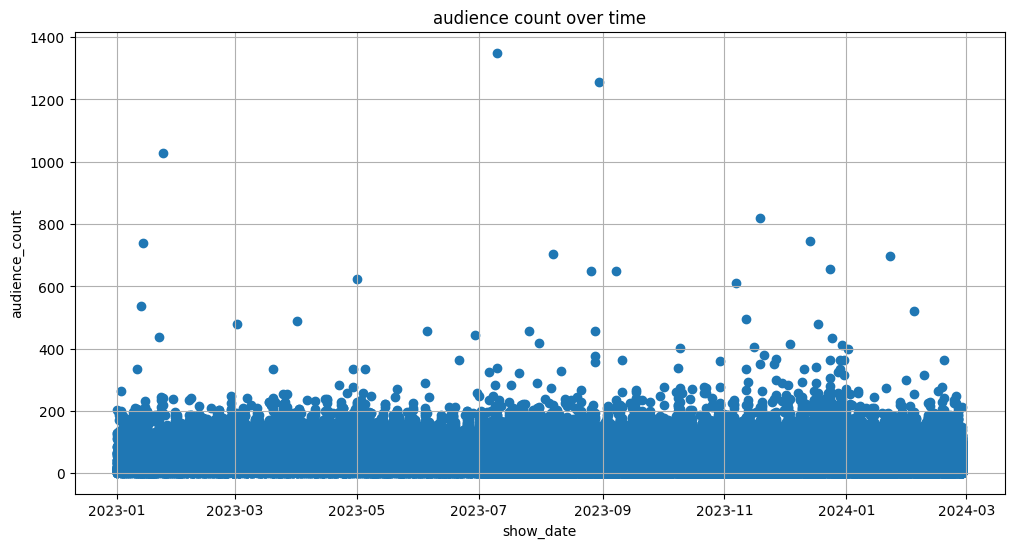

In [103]:
# visualization of audience over time
plt.figure(figsize = (12,6))
plt.scatter(booknow_visits['show_date'],booknow_visits['audience_count'])
plt.title('audience count over time')
plt.xlabel('show_date')
plt.ylabel('audience_count')
plt.xticks(rotation = True)
plt.grid(True)
plt.show()


In [111]:
daily_bookings.head()

,book_theater_id,show_date,total_tickets,booking_events,avg_tickets
0,book_00004,2023-02-27,12,1,12.000000
1,book_00013,2023-01-04,2,1,2.000000
2,book_00013,2023-01-08,3,1,3.000000
3,book_00013,2023-01-09,25,12,2.083333
4,book_00013,2023-01-10,5,2,2.500000


In [82]:
df.columns

Index(['book_theater_id', 'show_date', 'audience_count', 'day_of_week',
       'theater_type', 'theater_area', 'total_tickets', 'booking_events',
       'avg_tickets', 'year', 'month', 'day', 'quarter', 'week', 'is_weekend',
       'audience_lag_1', 'audience_lag_3', 'audience_lag_7',
       'audience_roll_mean_7', 'audience_roll_mean_14', 'theater_avg',
       'theater_std', 'theater_min', 'theater_max', 'dow_avg'],
      dtype='object')

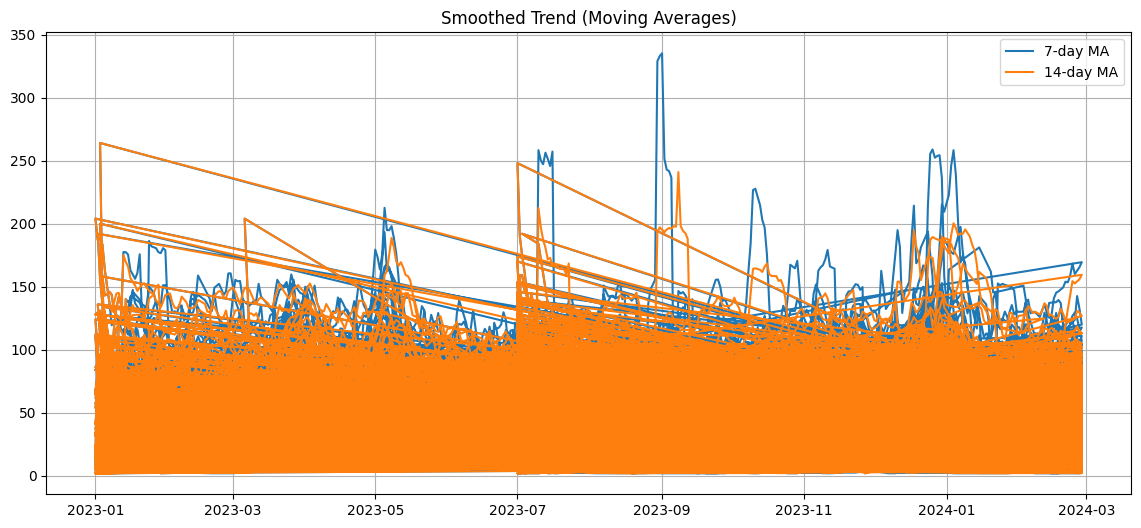

In [113]:
plt.figure(figsize=(14,6))
plt.plot(df['show_date'], df['audience_roll_mean_7'], label='7-day MA')
plt.plot(df['show_date'], df['audience_roll_mean_14'], label='14-day MA')
plt.legend()
plt.title("Smoothed Trend (Moving Averages)")
plt.grid(True)
plt.show()


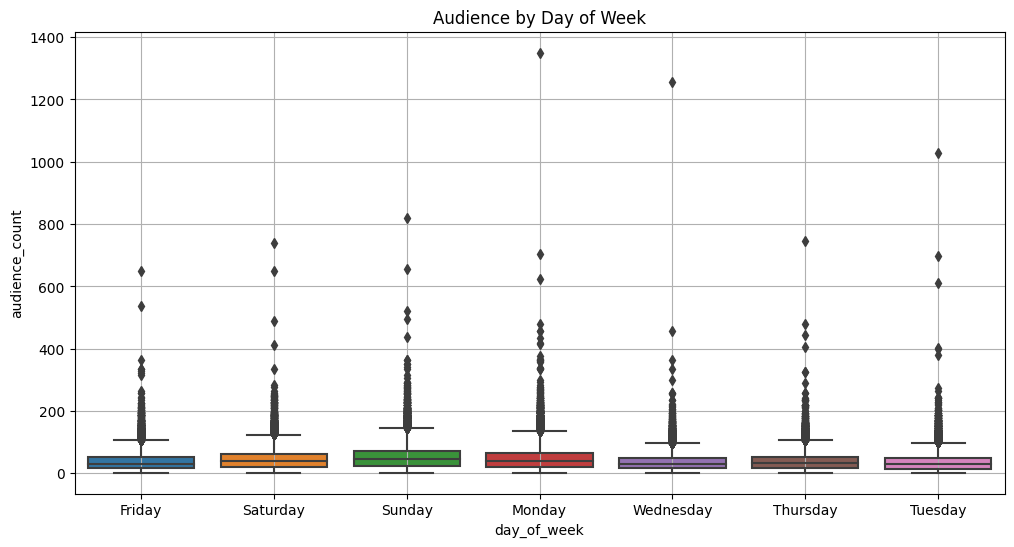

In [117]:
plt.figure(figsize = (12,6))
sns.boxplot(x='day_of_week', y='audience_count', data=df)
plt.title("Audience by Day of Week")
plt.grid(True)
plt.show()


# Data Split and Transformation

In [197]:
# transforming the categorical columns
le_dict = {}
for col in ['theater_type', 'theater_area', 'day_of_week']:
    if col in df.columns and df[col].dtype == 'object':
        le = LabelEncoder()
        df[col + '_encoded'] = le.fit_transform(df[col].astype(str))
        le_dict[col] = le

In [198]:
#splitting the data in train and split
split_date = df['show_date'].max() - pd.Timedelta(days=90)

train_data = df[df['show_date'] <= split_date].copy()
test_data = df[df['show_date'] > split_date].copy()

In [199]:
# numeri features
numeric_features = [
    'total_tickets', 'booking_events', 'avg_tickets',
    'month', 'day', 'quarter', 'week', 'is_weekend',
    'audience_lag_1', 'audience_lag_3', 'audience_lag_7',
    'audience_roll_mean_7', 'audience_roll_mean_14',
    'theater_avg', 'theater_std', 'theater_min', 'theater_max', 'dow_avg'
]

# categorical features
categorical_features = ['theater_type_encoded', 'theater_area_encoded', 'day_of_week_encoded']

feature_cols = [f for f in numeric_features + categorical_features if f in train_data.columns]

X_train = train_data[feature_cols].copy()
y_train = train_data['audience_count'].copy()

X_test = test_data[feature_cols].copy()
y_test = test_data['audience_count'].copy()


In [200]:
# first i encoded the caategorical columns and then using standarScaler i scale them

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [201]:
models = {
    'RandomForest': RandomForestRegressor(n_estimators=100, max_depth=12, min_samples_leaf=5, random_state=42, n_jobs=-1),
    'GradientBoosting': GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42, verbosity=0)
}

sim_results = {}





In [202]:
# testing the models

for name, model in models.items():
    print(f"  training {name}__", end=' ')
    model.fit(X_train_scaled, y_train)
    
    y_pred_train = model.predict(X_train_scaled)
    y_pred_test = model.predict(X_test_scaled)
    
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    test_r2 = r2_score(y_test, y_pred_test)
    
    sim_results[name] = {
        'model': model,
        'train_mae': train_mae,
        'test_mae': test_mae,
        'train_rmse': train_rmse,
        'test_rmse': test_rmse,
        'r2': test_r2,
        'predictions': y_pred_test
    }
    
    print(f"mae: {test_mae:.2f}, rmse: {test_rmse:.2f}, R²: {test_r2:.3f}")

  training RandomForest__ mae: 13.31, rmse: 19.88, R²: 0.643
  training GradientBoosting__ mae: 13.41, rmse: 20.27, R²: 0.629
  training XGBoost__ mae: 13.35, rmse: 19.95, R²: 0.640


# Comparison of Models

In [203]:
print(f"{'model':<20} {'train mae':<12} {'test mae':<12} {'test rmse':<12} {'r2_score':<12}")


best_model = None
best_score = float('inf')

for name, metrics in sim_results.items():
    print(f"{name:<20} {metrics['train_mae']:<12.2f} {metrics['test_mae']:<12.2f} {metrics['test_rmse']:<12.2f} {metrics['r2']:<12.3f}")
    
    if metrics['test_mae'] < best_score:
        best_score = metrics['test_mae']
        best_model = name

print(f"\n Best Model: {best_model} (Test MAE: {best_score:.2f})")

model                train mae    test mae     test rmse    r2_score    
RandomForest         12.21        13.31        19.88        0.643       
GradientBoosting     12.93        13.41        20.27        0.629       
XGBoost              12.93        13.35        19.95        0.640       

 Best Model: RandomForest (Test MAE: 13.31)


# Hyper Parameter Tunning

In [204]:
from sklearn.model_selection import RandomizedSearchCV

In [205]:
#results  = {}
# RandomForest = {'n_estimators':[150,250,350],
#                     'max_depth':[8,12,15],
#                     'min_samples_leaf':[1,3,5,10]
#                     }
# GradientBoosting = {'n_estimators':[150,200,250],
#                      'learning_rate':[0.015,0.03,0.05,0.1],
#                      'max_depth':[5,10,15,]}

# XGBoost = {
#     'n_estimators': [150,200, 250],
#     'learning_rate': [0.01, 0.05, 0.1],
#     'max_depth': [3, 5, 7, 10],
#     'min_child_weight': [1, 3, 5],
#     'subsample': [0.6, 0.8, 1.0],
#     'reg_alpha': [0, 0.01, 0.1],
#     'reg_lambda': [1, 3, 5]  
# }

# param_grids = {
#     'RandomForest': RandomForest,
#     'GradientBoosting': GradientBoosting,
#     'XGBoost': XGBoost
# }

# for name, model in models.items():
#     print(f"\n RandomizedSearch for {name}...")

#     rand_search = RandomizedSearchCV(
#         estimator=model,
#         param_distributions=param_grids[name],
#         n_iter=40,
#         scoring='neg_mean_absolute_error',
#         cv=3,
#         n_jobs=-1,
#         verbose=2,
#         random_state=42
#     )
    
#     rand_search.fit(X_train, y_train)

#     best_model = rand_search.best_estimator_
#     y_pred = best_model.predict(X_test)

#     results[name] = {
#         'Best Params': rand_search.best_params_,
#         'MAE': mean_absolute_error(y_test, y_pred),
#         'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
#         'Model': best_model
#     }

#     print(f"Best Params: {rand_search.best_params_}")
#     print(f"MAE: {results[name]['MAE']:.4f}")
#     print(f"RMSE: {results[name]['RMSE']:.4f}")





In [212]:
# print(f"Best Params: {rand_search.best_estimator_}")
# hft_best_model = rand_search.best_estimator_
# results

In [207]:
sim_results

{'RandomForest': {'model': RandomForestRegressor(max_depth=12, min_samples_leaf=5, n_jobs=-1,
                        random_state=42),
  'train_mae': 12.207267551781626,
  'test_mae': 13.31455906471607,
  'train_rmse': 18.11382291618259,
  'test_rmse': 19.882773310829446,
  'r2': 0.6427581833681948,
  'predictions': array([37.11545232, 44.95160596, 56.75766088, ..., 15.84537297,
         12.12361726, 14.88241233])},
 'GradientBoosting': {'model': GradientBoostingRegressor(max_depth=5, random_state=42),
  'train_mae': 12.929545506659464,
  'test_mae': 13.412527738652726,
  'train_rmse': 18.59751513049089,
  'test_rmse': 20.272545277935944,
  'r2': 0.6286145156778957,
  'predictions': array([32.15276645, 39.32714061, 53.68479553, ..., 14.48920852,
         12.31932074, 13.60967165])},
 'XGBoost': {'model': XGBRegressor(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=None, device=None, early_stop

In [208]:
# creating a dataframe of metrics

df_results = pd.DataFrame([
    {
        'Model': m,
        'Train MAE': sim_results[m]['train_mae'],
        'Test MAE': sim_results[m]['test_mae'],
        'Train RMSE': sim_results[m]['train_rmse'],
        'Test RMSE': sim_results[m]['test_rmse'],
        'R2 Score': sim_results[m]['r2']
    }
    for m in sim_results
])


df_results.sort_values(by='Test MAE')






,Model,Train MAE,Test MAE,Train RMSE,Test RMSE,R2 Score
0,RandomForest,12.207268,13.314559,18.113823,19.882773,0.642758
2,XGBoost,12.933209,13.352042,18.907237,19.946771,0.640455
1,GradientBoosting,12.929546,13.412528,18.597515,20.272545,0.628615


# Metrics Visualization

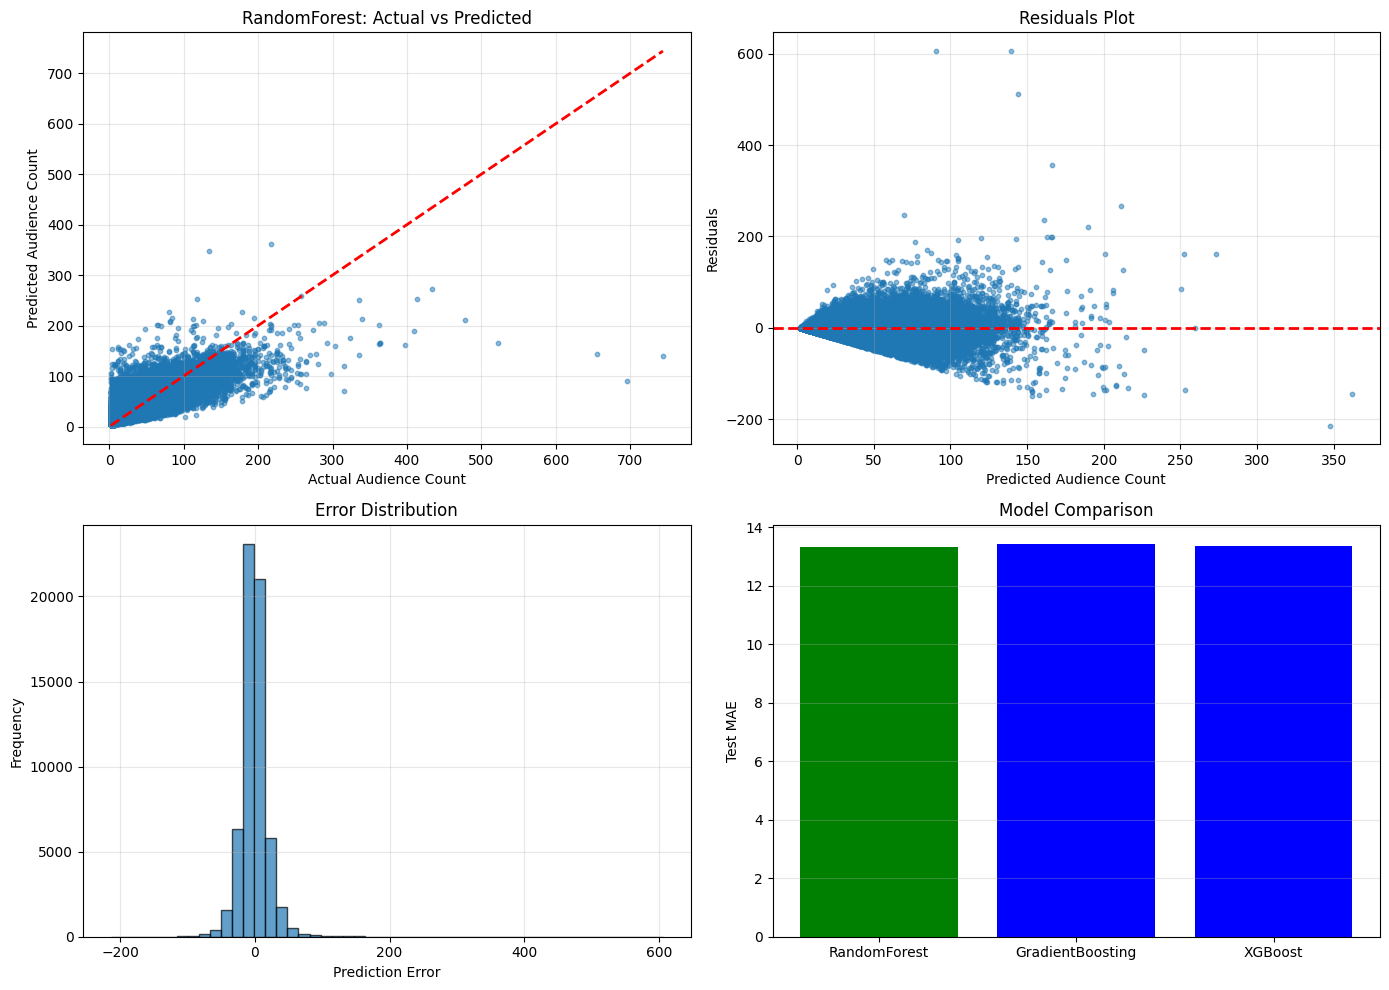

In [209]:
best_predictions = sim_results[best_model]['predictions']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))


axes[0, 0].scatter(y_test, best_predictions, alpha=0.5, s=10)
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Audience Count')
axes[0, 0].set_ylabel('Predicted Audience Count')
axes[0, 0].set_title(f'{best_model}: Actual vs Predicted')
axes[0, 0].grid(True, alpha=0.3)


residuals = y_test - best_predictions
axes[0, 1].scatter(best_predictions, residuals, alpha=0.5, s=10)
axes[0, 1].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Predicted Audience Count')
axes[0, 1].set_ylabel('Residuals')
axes[0, 1].set_title('Residuals Plot')
axes[0, 1].grid(True, alpha=0.3)


axes[1, 0].hist(residuals, bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].set_xlabel('Prediction Error')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Error Distribution')
axes[1, 0].grid(True, alpha=0.3)


model_names = list(sim_results.keys())
test_maes = [sim_results[m]['test_mae'] for m in model_names]
axes[1, 1].bar(model_names, test_maes, color=['green' if m == best_model else 'blue' for m in model_names])
axes[1, 1].set_ylabel('Test MAE')
axes[1, 1].set_title('Model Comparison')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()


# Building Submission File

In [210]:
sample['parts'] = sample['ID'].str.rsplit('_', n=1, expand=False)
sample[['book_theater_id_s', 'show_date_s']] = sample['ID'].str.rsplit('_', n=1, expand=True)
sample['show_date_s'] = pd.to_datetime(sample['show_date_s'])


submission_data = sample[['ID', 'book_theater_id_s', 'show_date_s']].copy()
submission_data.columns = ['ID', 'book_theater_id', 'show_date']

submission_data = submission_data.merge(date_info, on='show_date', how='left')
submission_data = submission_data.merge(booknow_theater[['book_theater_id', 'theater_type', 'theater_area']], on='book_theater_id', how='left')
submission_data = submission_data.merge(daily_bookings, on=['book_theater_id', 'show_date'], how='left')

for col in ['total_tickets', 'booking_events', 'avg_tickets']:
    submission_data[col] = submission_data[col].fillna(0)

submission_data['year'] = submission_data['show_date'].dt.year
submission_data['month'] = submission_data['show_date'].dt.month
submission_data['day'] = submission_data['show_date'].dt.day
submission_data['quarter'] = submission_data['show_date'].dt.quarter
submission_data['week'] = submission_data['show_date'].dt.isocalendar().week.astype(int)
submission_data['is_weekend'] = submission_data['day_of_week'].isin(['Saturday', 'Sunday']).astype(int)

submission_data = submission_data.merge(theater_stats, on='book_theater_id', how='left')
submission_data = submission_data.merge(dow_stats, on='day_of_week', how='left')

submission_data['theater_avg'] = submission_data['theater_avg'].fillna(df['theater_avg'].mean())
submission_data['theater_std'] = submission_data['theater_std'].fillna(df['theater_std'].mean())
submission_data['theater_min'] = submission_data['theater_min'].fillna(df['theater_min'].mean())
submission_data['theater_max'] = submission_data['theater_max'].fillna(df['theater_max'].mean())


for col in ['audience_lag_1', 'audience_lag_3', 'audience_lag_7', 'audience_roll_mean_7', 'audience_roll_mean_14']:
    submission_data[col] = submission_data['theater_avg']


for col in ['theater_type', 'theater_area', 'day_of_week']:
    if col in le_dict:
        submission_data[col + '_encoded'] = le_dict[col].transform(submission_data[col].astype(str))


X_submit = submission_data[feature_cols].copy()
X_submit_scaled = scaler.transform(X_submit)

print(f" Submission features prepared: {X_submit.shape}")






 Submission features prepared: (38062, 21)


# Prediction on Best Model

In [211]:

best_model_obj = sim_results[best_model]['model']

y_submit = best_model_obj.predict(X_submit_scaled)


y_submit = np.maximum(0, np.round(y_submit)).astype(int)


submission_df = pd.DataFrame({
    'ID': sample['ID'],
    'audience_count': y_submit
})

submission_df.to_csv('/kaggle/working/submission.csv', index=False)

print(f"prediction: {len(y_submit)} records")


print("submisssion_data: \n")
print(submission_df.head(10))

print("statistics on prediction:\n")

print(submission_df['audience_count'].describe())


prediction: 38062 records
submisssion_data: 

                      ID  audience_count
0  book_00001_2024-03-01              42
1  book_00001_2024-03-02              48
2  book_00001_2024-03-03              52
3  book_00001_2024-03-04              48
4  book_00001_2024-03-06              42
5  book_00001_2024-03-07              43
6  book_00001_2024-03-08              42
7  book_00001_2024-03-09              49
8  book_00001_2024-03-10              53
9  book_00001_2024-03-11              49
statistics on prediction:

count    38062.000000
mean        41.739635
std         21.762134
min          2.000000
25%         25.000000
50%         37.000000
75%         57.000000
max        185.000000
Name: audience_count, dtype: float64
